# Weight perturbation

## Theory

### Gradient descent optimization

Most deep learning algorithms involve optimization of some sort. Optimization
refers to the task of either minimizing or maximizing some function $f(x)$ by altering
$x$. We usually phrase most optimization problems in terms of minimizing $f(x)$. Maximization may be accomplished via a minimization algorithm by minimizing $-f(x)$. The function we want to minimize or maximize is called the objective function or criterion. When we are minimizing it, we may also call it the cost
function, loss function, or error function [3, p. 82].

We can decrease $f$ by moving in the direction of the negative gradient.
This is known as the method of steepest descent or gradient descent. A new point is then given by:
$$
x' = x - \eta \nabla_x f(x)
$$
where $\eta$ is the learning rate (step size) [3, p. 85,86].

### Weight perturbation
Consider a network getting input over a trial duration $T$ and generating output. Time is split into discrete steps, indexed by $t = 1, \dots , T$. At the end of a trial, it receives a scalar
error feedback $E$ about its performance.
To quantitatively introduce the learning rules, we consider a neuron $i$, which may be part of a larger network.
It generates in the $t$-th time bin an output firing rate $z_{it}$,
in response to the firing rates $r_{jt}$ of its $N$ presynaptic
neurons 
$$
z_{it} = g \left(\sum_{j=1}^N w_{ij} \cdot r_{jt} \right) 
$$
Here $g$ is the activation function (example sigmoid). 

Weight perturbation now happens when we add a (for example Gaussian distributed with mean 0 and standard deviation $\sigma$) noise $\epsilon$ to the weights at the beginning of each trial:
$$
z_{it}' = g \left(\sum_{j=1}^N \left[w_{ij} + \epsilon_{ij} \right]\cdot r_{jt} \right) 
$$
where the first two moments of the noise are 
$$
\braket{\epsilon_{ij}} = 0, \qquad \braket{\epsilon_{ij} \epsilon_{kl}} = \delta_{kl} \delta_{ij} \sigma^2
$$
In the following we introduce the learning rate $\eta$, the error of the perturbed trial $E' = E(w + \epsilon)$ and the error of the unperturbed trial $E(w)$. The errors will here be calculated via the squared differences of predicted and true output. The update rule we will use is given by [1, page 2]:
$$
\Delta w_{ij} = -\frac{\eta}{\sigma^2} (E'-E)\cdot \epsilon_{ij}
$$
and is in the average equal to gradient descent optimization. Using the Taylor expansion
$$
E' = E + \sum_{k,l} \left. \frac{\partial E(w_{kl} + \epsilon_{kl})}{\partial (w_{kl} + \epsilon_{kl})} \right|_{\epsilon_{kl} = 0} \cdot \epsilon_{kl} + \mathcal{O}(\epsilon_{kl}^2) \approx E + \sum_{k,l} \frac{\partial E}{\partial w_{kl}} \cdot \epsilon_{kl}
$$
this expression can be rewritten to:
\begin{align*}
 \Delta w_{ij} &= -\frac{\eta}{\sigma^2} (E'-E)\cdot \epsilon_{ij} \\
 & \approx -\frac{\eta}{\sigma^2} \left( \sum_{k,l} \frac{\partial E}{ \partial w_{kl}} \, \epsilon_{kl} \right) \cdot \epsilon_{ij}
\end{align*}
If one now takes the average this yields
\begin{align*}
 \braket{\Delta w_{ij}} &\approx -\frac{\eta}{\sigma^2} \left( \sum_{k,l} \frac{\partial E}{ \partial w_{kl}} \, \braket{\epsilon_{kl} \cdot \epsilon_{ij}} \right)\\
 & = -\frac{\eta}{\sigma^2} \left( \sum_{k,l} \frac{\partial E}{ \partial w_{kl}} \, \delta_{ki} \delta_{lj} \sigma^2 \right) \\
 & = - \eta \frac{\partial E}{ \partial w_{ij}} 
\end{align*}

## Simple spiking networks
We will now construct a simple, single layer neural network. We will use three input neurons and one output neuron. The Inputs $I_1, I_2, I_2$ are $n$-dimensional, binary vectors. The weights $w_1,w_2,w_3$ will be trained such that a desired output can be reached.  The used update rule is the WP rule from above. Additionally, we consider 3 different activation functions: sigmoid, linear and step-function. Additionally, the weight and error convergence will be plotted and described.

### Import packages

In [48]:
# Import packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import random
import seaborn as sns

# Plot specifications
import matplotlib
matplotlib.rcParams['mathtext.fontset'] = 'stix'
matplotlib.rcParams['font.family'] = 'STIXGeneral'
matplotlib.rcParams['legend.fontsize']  = 14
matplotlib.rcParams['xtick.labelsize']  = 14
matplotlib.rcParams['ytick.labelsize']  = 14
matplotlib.rcParams['axes.titlesize']  = 17
matplotlib.rcParams['axes.labelsize']  = 17



# Plot two given lists x and y against each other
def visualize(x, y, data_label, xlabel, ylabel, color, linestyle='.', transparency = 1):
    # Plot the data
    plt.plot(x, y, linestyle, color=color, alpha=transparency)
    plt.ylabel(ylabel)
    plt.xlabel(xlabel)
    plt.grid(alpha=0.3)
    #plt.legend()

### Create a teacher function

In order to generate some reachable output, we create a teacher function, that takes the same inputs as the neuron and has some specific weight values $w_1^*, w_2^*, w_3^*$. These are then used to calculate the target output, yielding a reachable output for our network. 

### Create complete network

Now we set up the complete network, where a the teacher can be used or not. The weights are computed via the WP algorithm and the weight values as well as the error for each training epoch will be plotted. From the theory we expect the error to converge exponentially towards some final error. Also for WP we do not expect the error to become greater at any point.

In [49]:
import random

class linear_perceptron:
    
    def __init__(self,
        eta,  # Learning rate
        sigma,  # std of the gaussian noise
        T,  # Vector length
        num_iterations,  # Number of iterations for weight update
        activation_type,  # Set activation function
        use_teacher,  # Use a teacher function to generate target
        plot_weight,  # Wether the evolution of weights should be plotted
        spike_number,  # Number of total spikes
        input_neuron_number,  # Number of neurons in input layer
        plot_errors = True,  # Wether to plot the error evolution
        sigma_0 = 1,  # Value of start weight std
        ):
        
        self.sigma = sigma / np.sqrt(input_neuron_number*spike_number/T)
        self.T = T
        self.num_iterations = num_iterations
        self.activation_type = activation_type
        self.use_teacher = use_teacher
        self.plot_weight = plot_weight
        self.input_neuron_number =  input_neuron_number 
        self.spike_number = spike_number
        self.input_strength = self.spike_number/self.T
        self.eta = eta
        self.plot_errors = plot_errors
        self.sigma_0 = sigma_0
        # Collect errors for plot
        self.err = []
        self.err_WP = []
        # Collect first 3 weight values for plot
        self.w1 = []
        self.w2 = []
        self.w3 = []
       
   
    #----------------------------------------------------#
    #             Generate incoming spike train
    #----------------------------------------------------#  
    def spike_train(self):
        # Setting a seed, which garantees reproducebility of the trial
        random.seed(43)  
        # Set underground
        underground = np.zeros((self.input_neuron_number, self.T))
        # Generate spikes
        signal = underground
        for input_neuron in range(0,self.input_neuron_number):
            index = random.sample(range(0, self.T), self.spike_number)
            for spike_time in index:
                # The amplitude of spikes
                spike_amplitude = 1 
                # Combine spikes with underground
                signal[input_neuron][spike_time] = spike_amplitude
        return signal
    
       
    #----------------------------------------------------#
    #        Set start, teacher weights and target
    #----------------------------------------------------# 
        # Define teacher output 
    def teacher(self):
        # Create a RandomState object with a seed for reproducebility
        rng = np.random.RandomState(42)
        # Define target values for the weights
        self.teacher_weights = rng.normal(0, np.sqrt(self.T/(self.spike_number*self.input_neuron_number)), self.input_neuron_number)
        # Define the expected output based on the teacher weights
        self.expected_output = self.neuron(self.inputs, self.teacher_weights)
        
    # Initialize network weights and input
    def init_network(self):            
        # Initialize random weight values 
        self.weights = np.random.normal(0, 1, self.input_neuron_number)  
        # Initialize random spike inputs
        self.inputs = self.spike_train()
        # Generate target
        if self.use_teacher == True:
            self.teacher()
        else:
            self.expected_output = np.random.randint(0, 2, size=(self.T)) 
    
    
    #----------------------------------------------------#
    #       Set neuron function and errors/updates
    #----------------------------------------------------# 
    # Define the operation of the neuron
    def neuron(self, inputs, weights):
        I_t = np.dot(weights,inputs)
        
        out = self.activation_func(I_t)
        return out    
        
    # Define activation function for three different functions
    def activation_func(self, x):
        z=0
        if self.activation_type == "linear":
            z = x 
        elif self.activation_type == "sigmoid":
            z = 1.0/(1.0 + np.exp(-x)) 
        return z

    # Calculate the errors of the network predicitons
    def E(self, output, true_value):
        v = np.array(true_value) - np.array(output)
        return (1/(2*self.T)) * np.sum(v**2)  # scalar output

    # Define the update rule
    def weight_update(self, E_WP, E, noise):
        dw = - (self.eta/self.sigma**2) * (E_WP - E) * noise 
        return dw  
    
    
    #---------------------------------------------------------------------#
    #                            Plot weights
    #---------------------------------------------------------------------#
    def plot_weight_error_evoltion(self):
        xspace = np.linspace(0,self.num_iterations, self.num_iterations)
        # Plot weight evolution
        if self.plot_weight == True:
            # Plotting only the first three weights
            visualize(xspace, self.w1, 'w1', 'Num iteration', 'Weight value', color='grey', linestyle='-', transparency=0.5)
            visualize(xspace, self.w2, 'w2', 'Num iteration', 'Weight value', color='orange', linestyle='-', transparency=0.5)
            visualize(xspace, self.w3, 'w3', 'Num iteration', 'Weight value', color='red', linestyle='-', transparency=0.5)
            # Plot the teacher weights
            plt.hlines(self.teacher_weights[0], -5, self.num_iterations + 5,  linestyles='--', color='grey')
            plt.hlines(self.teacher_weights[1], -5, self.num_iterations + 5, linestyles='--', color='orange')
            plt.hlines(self.teacher_weights[2], -5, self.num_iterations + 5, linestyles='--', color='red')
            plt.title(f'Activation func: {self.activation_type}')
            plt.show()
        # Plot the (perturbed and unperturbed) error evolution of the trial
        if self.plot_errors == True:
            visualize(xspace, self.err, r'$E$', r'$n$', r'$E(n)$', color='blue', linestyle='-')
            #visualize(xspace, self.err_WP, r'$E^\mathrm{pert}$', r'$n$', r'$E(n)$', color='green', linestyle='--', transparency=0.5)
            plt.title(f'Aktivierungsfunktion: {self.activation_type}')
            #plt.savefig(f'Err_{self.activation_type}_entwicklung_starkeperts.pdf')            
            plt.show()
            

    #---------------------------------------------------------------------#
    #                            Train network
    #---------------------------------------------------------------------#
    # Train the network using weight perturbation
    def network_training(self):            
        # Initialize network (wet weights and input)
        self.init_network()
        
        # Training
        for epoch in range(0,self.num_iterations):
            # Save weight value to list
            self.w1.append(self.weights[0])
            self.w2.append(self.weights[1])
            self.w3.append(self.weights[2])
            
            # Reset output vector
            output = []
            output_WP = []
            # Define the noise
            noise = self.sigma * np.random.normal(loc=0., scale=1, size=(self.input_neuron_number,1)).flatten()
  
            # Unperturbed activations
            output = self.neuron(self.inputs, self.weights)  
            # Perturbed activations
            output_WP = self.neuron(self.inputs, self.weights + noise)
                
            # Compute the loss
            e = self.E(output, self.expected_output)
            e_WP = self.E(output_WP, self.expected_output)
            self.err.append(e)
            self.err_WP.append(e_WP)
                
            # Update the weights
            self.weights += self.weight_update(e_WP, e, noise) 
            
        # Give out the output
        output = self.neuron(self.inputs, self.weights)
        # Call plot function
        self.plot_weight_error_evoltion()
        return output, self.expected_output, self.err, self.err_WP
    
    
    
    def weight_scan_plot(self, index, min, max, y_lim1, y_lim2, title):
        ERR = []
        w = np.linspace(min,max,2000)
        w_trained = 1*self.weights
        # Iterate over possible weight values
        for w_i in w:
            w_trained[index] = w_i
            OUT = self.neuron(self.inputs, w_trained) 
            ERR.append(self.E(OUT, self.expected_output))

        # Plot err
        plt.plot(w, ERR, label='Fehler',)
        plt.vlines(w[ERR.index(np.min(np.array(ERR)))], -1, 3, color='red', label=r'$\mathrm{min}(E)$')
        # Plot trained weight
        plt.vlines(self.weights[index], -1,3, color='grey', linestyles='dashed', label='Trainiertes Gewicht')
        plt.vlines(self.teacher_weights[index], -1,3, color='orange', linestyles='dashed', label='Teacher Gewicht')
        # Plot specifications
        plt.grid(alpha=0.3)
        plt.ylabel(r'$E$')
        plt.xlabel(r'$w_i$')
        plt.ylim(y_lim1, y_lim2)
        plt.legend(loc='upper left')
        plt.title(title)
        #plt.savefig(f'{self.activation_type}function_singleweight_change.pdf')
        

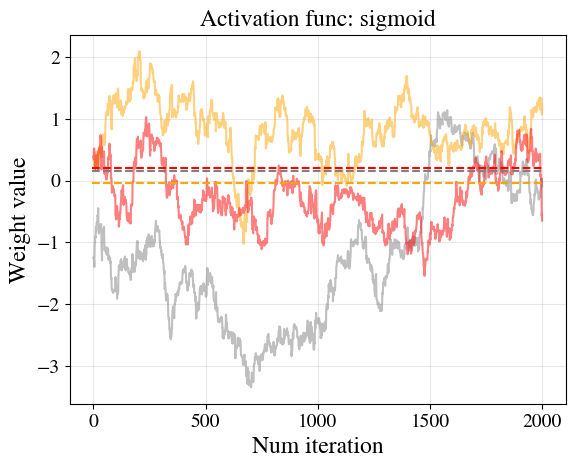

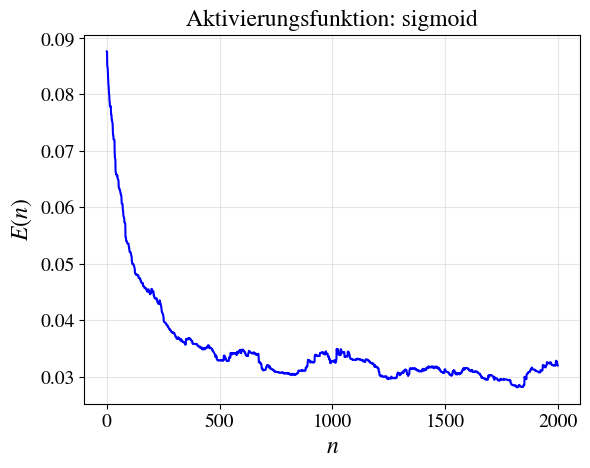

In [50]:
#---------------------------------------------------------------------#
#                          Execute network
#---------------------------------------------------------------------#
for activation in ['sigmoid']:
        if activation=='sigmoid':
                sigma=0.001
                eta = 12#4
                num_iterations = 2000
        elif activation=='linear':
                sigma=0.001
                eta = 0.1
                num_iterations = 200
        # Create network instance
        readout = linear_perceptron(
                eta = eta,  # learning rate
                sigma = sigma,  # std of the gaussian noise
                T = 200,  # Vector length
                num_iterations = num_iterations,  # Number of iterations for weight update
                activation_type = activation,  # Set activation function
                use_teacher = True,  # Use teacher function
                plot_weight = True,  # Plot the weight evolution
                spike_number = 10,  # Total number of spikes
                input_neuron_number = 200,  # Number of neurons in input layer
        )

        # Train network
        output, expected_output, err, err_WP = readout.network_training()


# Step function final error

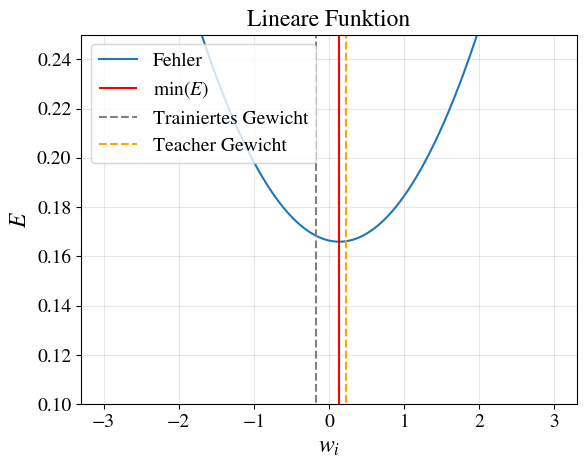

In [51]:
#---------------------------------------------------------------------#
#                          Execute network
for activation in ['linear']:
        if activation=='sigmoid':
                sigma=0.001
                eta = 4
                num_iterations = 500
        elif activation=='linear':
                sigma=0.001
                eta = 0.1
                num_iterations = 500
        # Create network instance
        readout = linear_perceptron(
                eta = eta,  # learning rate
                sigma = sigma,  # std of the gaussian noise
                T = 200,  # Vector length
                num_iterations = num_iterations,  # Number of iterations for weight update
                activation_type = activation,  # Set activation function
                use_teacher = True,  # Use teacher function
                plot_weight = False,  # Plot the weight evolution
                spike_number = 10,  # Total number of spikes
                input_neuron_number = 100,  # Number of neurons in input layer
                plot_errors=False
        )

        # Train network
        output, expected_output, err, err_WP = readout.network_training()
        readout.weight_scan_plot(0, -3,3, y_lim1=0.1, y_lim2=0.25, title='Lineare Funktion')

# Compare step function with special case of sigmoid

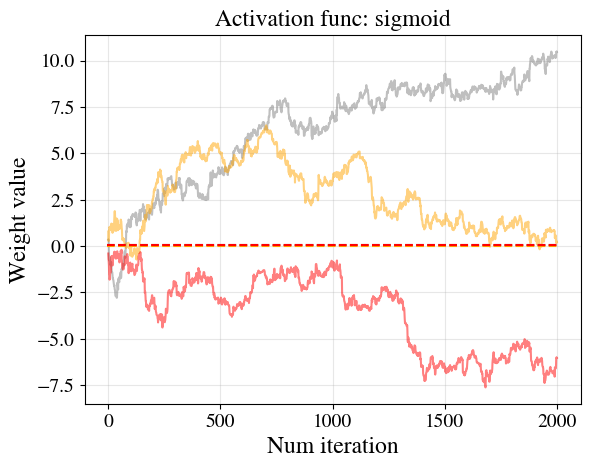

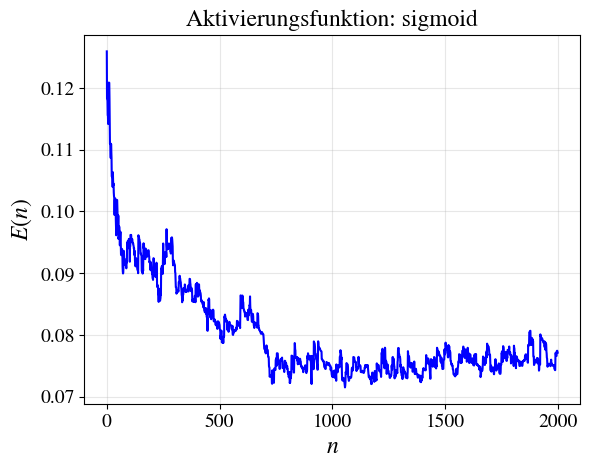

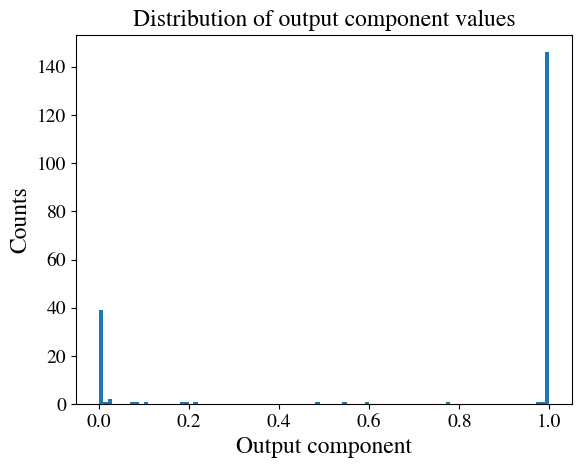

In [52]:
#---------------------------------------------------------------------#
#                          Execute network
#---------------------------------------------------------------------#
for activation in ['sigmoid']:
        sigma=0.1
        eta = 15
        num_iterations = 2000
        # Create network instance
        readout = linear_perceptron(
                eta = eta,  # learning rate
                sigma = sigma,  # std of the gaussian noise
                T = 200,  # Vector length
                num_iterations = num_iterations,  # Number of iterations for weight update
                activation_type = activation,  # Set activation function
                use_teacher = True,  # Use teacher function
                plot_weight = True,  # Plot the weight evolution
                spike_number = 10,  # Total number of spikes
                input_neuron_number = 2000,  # Number of neurons in input layer
        )

        # Train network
        output, expected_output, err, err_WP = readout.network_training()
        
        # Plot Output distribution
        plt.hist(output, bins=100)
        plt.xlabel('Output component')
        plt.ylabel('Counts')
        plt.title('Distribution of output component values')
        plt.show()

# Mean error

In [53]:
def mean_err(activation,
             num_iterations, 
             accuracy, 
             dataframe_meanErr_name, 
             dataframe_stdErr_name, 
             sigma,
             eta,
             T = 200,
             N=100,
             spike_number=10,
             ):
    
    LIST = []
    for i in range(0,accuracy):
        # Create network instance
        readout = linear_perceptron(
                eta = eta,  # learning rate
                sigma = sigma,  # std of the gaussian noise
                T = T,  # Vector length
                num_iterations = num_iterations,  # Number of iterations for weight update
                activation_type = activation,  # Set activation function
                use_teacher = True,  # Use teacher function
                plot_weight = False,  # Plot the weight evolution
                spike_number = spike_number,  # Total number of spikes
                input_neuron_number = N,  # Number of neurons in input layer
                plot_errors=False,
                )

        # Train network
        output, expected_output, err, err_WP = readout.network_training()
        LIST.append(err)

    LIST = np.array(LIST)
    ERR_mean = []
    ERR_std = []
    for i in range(0,num_iterations):
        ERR_mean.append(np.mean(LIST[:,i]))
        ERR_std.append(np.std(LIST[:,i]))
    ERR_mean = np.array(ERR_mean)
    ERR_std = np.array(ERR_std)

    # Convert dictionary to DataFrame
    df1 = pd.DataFrame(ERR_mean)
    df2 = pd.DataFrame(ERR_std)

    # Save DataFrame as CSV
    df1.to_csv(dataframe_meanErr_name, index=False)
    df2.to_csv(dataframe_stdErr_name, index=False)

    # Give x-values for plot as return
    x = np.linspace(0,num_iterations-1, num_iterations)
    return x


# Plot data
def plot_mean_err(x, dataframe_meanErr_name, dataframe_stdErr_name, label='Mean error'):
    # Create a plot
    y = np.array(pd.read_csv(dataframe_meanErr_name, engine='python')).flatten()
    y_std = np.array(pd.read_csv(dataframe_stdErr_name, engine='python')).flatten()
    plt.plot(x, y, '-', label=label)
    
    plt.fill_between(x, np.maximum(y - y_std,0), np.maximum(y + y_std,0), alpha=0.3)
    # Titles and labels
    plt.xlabel(r'$n$')
    plt.ylabel(r'$E(n)$')
    plt.grid(alpha=0.3)
    plt.legend()

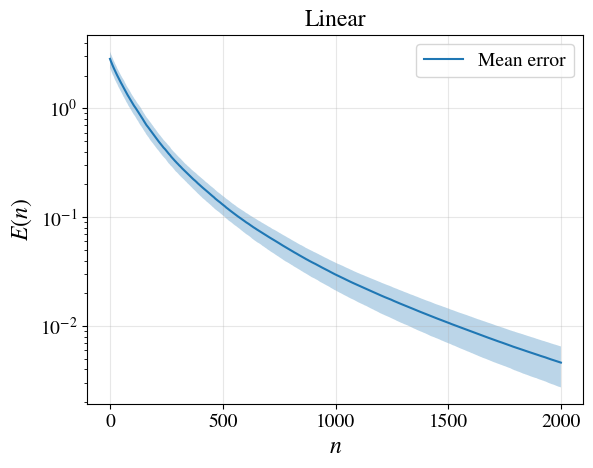

In [54]:
# # Generate data
# x = mean_err(activation='linear',
#         num_iterations = 2000, 
#         accuracy=100, 
#         dataframe_meanErr_name ='WP_MeanErr_linear', 
#         dataframe_stdErr_name ='WP_StdErr_linear', 
#         sigma=0.001,
#         eta=0.1
#         )
x = np.linspace(0,2000-1, 2000)
# Plot data
plot_mean_err(x, 'WP_MeanErr_linear', 'WP_StdErr_linear')
plt.title('Linear')
plt.yscale('log')
plt.savefig('WP_MeanErr_linear.pdf')
plt.show()

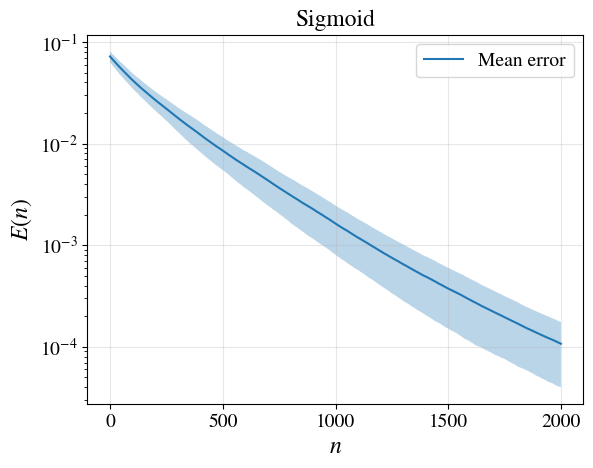

In [55]:
# # Generate data
# x = mean_err(
#         activation='sigmoid',
#         num_iterations = 2000, 
#         accuracy=100, 
#         dataframe_meanErr_name ='WP_MeanErr_sigmoid', 
#         dataframe_stdErr_name ='WP_StdErr_sigmoid', 
#         sigma=0.001,
#         eta=4,
#         )

# Plot data
plot_mean_err(x, 'WP_MeanErr_sigmoid', 'WP_StdErr_sigmoid')
plt.title('Sigmoid')
plt.yscale('log')
plt.savefig('WP_MeanErr_sigmoid.pdf')
plt.show()

In [ ]:
# Generate data
x = mean_err(
        activation='sigmoid',
        num_iterations = 20000, 
        accuracy=1, 
        dataframe_meanErr_name ='WP_MeanErr_sigmoid_perturbed', 
        dataframe_stdErr_name ='WP_StdErr_sigmoid_perturbed', 
        sigma=0.5,
        eta=1,
        spike_number=5,
        N=1000
        )

# Plot data
plot_mean_err(x, 'WP_MeanErr_sigmoid_perturbed', 'WP_StdErr_sigmoid_perturbed')
plt.title('Aktivierungsfunktion: sigmoid')
plt.savefig('WP_MeanErr_sigmoid_perturbed.pdf')
plt.show()

## Error dependency of the network parameters

In the following we want to investigate how the error depends on the network parameters, suhc as learning rate, noise strength and input structure. Therefore we iterate over these parameters multiple times and plot the mean and standard deviation of the resulting error in order to get an apropriate estimate of these dependencies.

### Optimal learning rate

We want to check for which value of $\eta$ the error converges the fastest to the final error $E_f$. From the theory we know that the optimal learning rate $\eta^*$ is given by [1, P.5]:
$$
\eta^* = \frac{1}{(M N_\mathrm{eff} + 2)\cdot \alpha^2}
$$
where $M$ is the number of linear perceptrons, $N_\mathrm{eff}$ the number of effective (orthogonal) nonzero inputs and $\alpha$ the input strength. Also an assumption for the derivation of this equation is that the input strengths for all inputs are equal $\alpha^2 = \alpha_i^2$ and that the activation function is linear. Moreover, the strength is given by [1, P.4]:
$$
\alpha^2 = \frac{1}{T} \sum_{t=1}^T r_{it}^2
$$
where $r_{it}$ is the amplitude of the i-th spike train at a time $t$. 

In the following we will examine if the expected value for the analytically derived $\eta^*$ corresponds to the numerically calculated one.

In [30]:

#------------------------------------------#
#     Calculate the error distribution
#------------------------------------------#

def Error_of_eta(
                activation,  # Type of activation function used
                std,  # Standard deviation of perturbation
                eta_max,  # Max value of eta for which the error is calculated
                eta_precision,  # number of eta values for the plot
                T,  # Spike train length
                input_neuron_number,  # Number of neurons in input layer
                dataframe_meanErr_name,  # Name of the dataframe of the mean errors
                dataframe_stdErr_name,  # Name of the dataframe of the std of the errors
                dataframe_plot_var_name,  # For some variables needed for plot
                accuracy,  # Set accuracy for the mean of error
                num_iterations,  # Numbre of iterations where the error will be examined
                spike_number,  # Number of spikes per neuron
                ):
    # Set values for std
    eta_spaces  = np.linspace(10**(-8), eta_max, eta_precision)

    # Create dicitonary to save error values
    Errors_mean = {f'{activation}' : [] }
    Errors_std = {f'{activation}': [] }
    
    for eta in eta_spaces:
        # Init params
        readout = linear_perceptron(
            eta = eta,  # Learning rate
            sigma = std,  # std of the gaussian noise
            T = T,  # Vector length
            num_iterations = num_iterations,  # Number of iterations for weight update
            activation_type = activation,  # Set activation function
            use_teacher = True,  # Use teacher function
            plot_weight=False,  # Wether to plot weight evolution
            spike_number = spike_number,  # Total number of spikes
            input_neuron_number = input_neuron_number,  # Number of neurons in input layer
            plot_errors = False,  # Wether to plot the error evolution
            )
        err_precision = []
        for i in range(0,accuracy):
            # Train network and generate output
            _ , _, err, _ = readout.network_training()
            err_precision.append(err[-1])
        
        Errors_mean[activation].append(np.mean(err_precision))
        Errors_std[activation].append(np.std(err_precision))      
            
            
    #---------------------------------------------------------------------#
    #                            Save plot data
    #---------------------------------------------------------------------#
    # Convert to numpy arrays 
    Errors_mean[activation] = np.array(Errors_mean[activation])
    Errors_std[activation] = np.array(Errors_std[activation])

    # Convert dictionary to DataFrame
    df1 = pd.DataFrame(Errors_mean)
    df2 = pd.DataFrame(Errors_std)

    # Save DataFrame as CSV
    df1.to_csv(dataframe_meanErr_name, index=False)
    df2.to_csv(dataframe_stdErr_name, index=False)


    # Calculate eta optimal
    alpha_sqr = spike_number/T
    eta_opt = 1/(alpha_sqr*(input_neuron_number+2))
    
    
    #---------------------------------------------------------------------#
    #                            Save plot data
    #---------------------------------------------------------------------#
    # Create a dictionary with some variables needed for plot 
    plot_var = {'eta_max' : [eta_max], 
                'eta_precision' : [eta_precision],
                'eta_opt' : [eta_opt],
                'activation' : [activation],
                'dataframe_meanErr_name' : [dataframe_meanErr_name],
                'dataframe_stdErr_name' : [dataframe_stdErr_name]}

    # Convert the dictionary into a pandas DataFrame
    df3 = pd.DataFrame(plot_var)

    # Save the DataFrame to a text file
    df3.to_csv(dataframe_plot_var_name, index=False)


#---------------------------------------------------------------------#
#                              Plot data
#---------------------------------------------------------------------#
# Define fit function
def plot_data(x, eta_opt, activation, dataframe_meanErr_name, dataframe_stdErr_name, title):
    # Plot data
    # Load data
    y = np.array(pd.read_csv(dataframe_meanErr_name, engine='python')).flatten()
    y_std = np.array(pd.read_csv(dataframe_stdErr_name, engine='python')).flatten()

    # Create a plot
    fig, ax = plt.subplots()
    ax.plot(x, y, '-', label='Mean error')
    ax.fill_between(x, y - y_std, y + y_std, alpha=0.2)
    # Plot eta opt
    plt.ylim(np.min(y) - np.min(y)/50, np.max(y) + np.max(y)/100)
    plt.xlim(np.min(x) - np.min(x)/100, np.max(x) + np.max(x)/100)
    #plt.vlines(eta_opt,-1,100,color='red', linestyles='--', label=r'$\eta^*$')
    # Titles and labels
    ax.set_title(title)
    ax.set_xlabel(r'$\bar{\eta}$')
    ax.set_ylabel(r'$E$')
    plt.grid(alpha=0.3)
    ax.legend()



In [31]:

# Error_of_eta(
#             activation='linear',  # Type of activation function used
#             std = 0.001,  # Standard deviation of perturbation
#             eta_max = 0.4,  # Max value of eta for which the error is calculated
#             eta_precision = 200,  # number of eta values for the plot
#             T = 200,  # Spike train length
#             input_neuron_number = 100,  # Number of neurons in input layer
#             dataframe_meanErr_name = 'Errors_mean(eta)_linear.csv',  # Name of the dataframe of the mean errors
#             dataframe_stdErr_name = 'Errors_std(eta)_linear.csv',  # Name of the dataframe of the std of the errors
#             dataframe_plot_var_name = 'plot_vars_linear.csv',  # For some variables needed for plot
#             accuracy = 100,  # Set accuracy for the mean of error
#             num_iterations = 100,  # Numbre of iterations where the error will be examined
#             spike_number = 10,  # Number of spikes per neuron
#             )

# Error_of_eta(
#             activation='sigmoid',  # Type of activation function used
#             std = 0.001,  # Standard deviation of perturbation
#             eta_max = 200,  # Max value of eta for which the error is calculated
#             eta_precision = 2000,  # number of eta values for the plot
#             T = 200,  # Spike train length
#             input_neuron_number = 100,  # Number of neurons in input layer
#             dataframe_meanErr_name = 'Errors_mean(eta)_sigmoid.csv',  # Name of the dataframe of the mean errors
#             dataframe_stdErr_name = 'Errors_std(eta)_sigmoid.csv',  # Name of the dataframe of the std of the errors
#             dataframe_plot_var_name = 'plot_vars_sigmoid.csv',  # For some variables needed for plot
#             accuracy = 100,  # Set accuracy for the mean of error
#             num_iterations = 100,  # Numbre of iterations where the error will be examined
#             spike_number = 10,  # Number of spikes per neuron
#             )

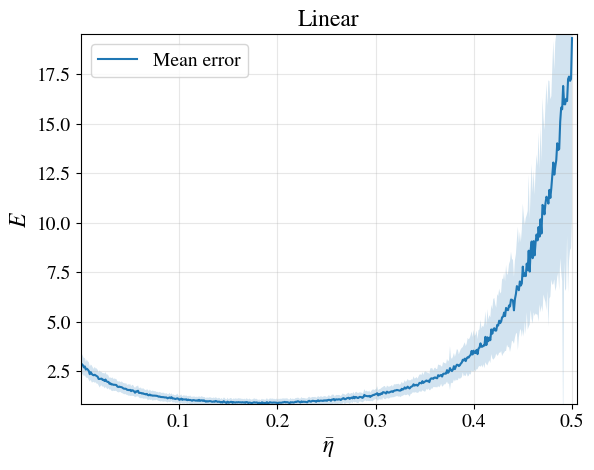

In [32]:
# Read the text file into a pandas DataFrame
df = pd.read_csv('plot_vars_linear.csv', engine='python')

eta_max = np.array(df['eta_max'])[0]
eta_precision = np.array(df['eta_precision'])[0]
eta_opt = df['eta_opt'][0]
activation = df['activation'][0]
dataframe_meanErr_name = df['dataframe_meanErr_name'][0]
dataframe_stdErr_name = df['dataframe_stdErr_name'][0]

eta_spaces  = np.linspace(10**(-8), eta_max, eta_precision)

plot_data(eta_spaces, eta_opt, activation, dataframe_meanErr_name, dataframe_stdErr_name, title='Linear')
plt.legend(loc='upper left')
plt.savefig('E(eta)_lin_entwicklung.pdf')
plt.show()

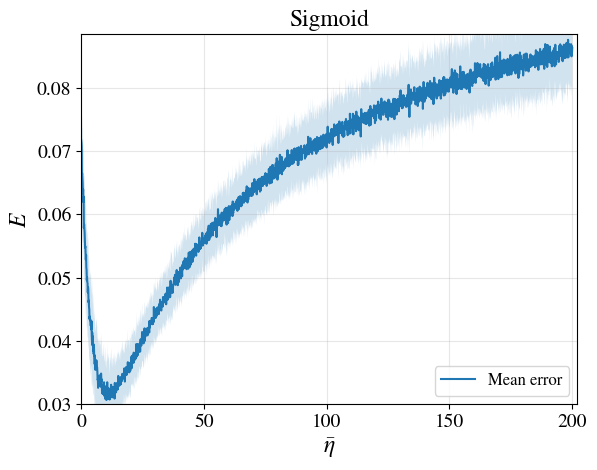

In [33]:
# Read the text file into a pandas DataFrame
df = pd.read_csv('plot_vars_sigmoid.csv', engine='python')

eta_max = np.array(df['eta_max'])[0]
eta_precision = np.array(df['eta_precision'])[0]
eta_opt = df['eta_opt'][0]
activation = df['activation'][0]
dataframe_meanErr_name = df['dataframe_meanErr_name'][0]
dataframe_stdErr_name = df['dataframe_stdErr_name'][0]

eta_spaces  = np.linspace(10**(-8), eta_max, eta_precision)

plot_data(eta_spaces, 5.8, activation, dataframe_meanErr_name, dataframe_stdErr_name, title='Sigmoid')
plt.savefig('E(eta)_sig_entwicklung.pdf')
plt.legend(loc='lower right', fontsize=12)
plt.show()

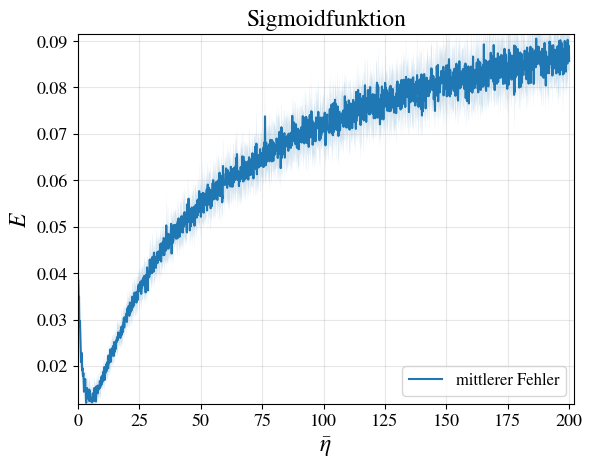

In [14]:
# Read the text file into a pandas DataFrame
df = pd.read_csv('plot_vars_smaesig_sigmoid.csv', engine='python')

eta_max = np.array(df['eta_max'])[0]
eta_precision = np.array(df['eta_precision'])[0]
eta_opt = df['eta_opt'][0]
activation = df['activation'][0]
dataframe_meanErr_name = df['dataframe_meanErr_name'][0]
dataframe_stdErr_name = df['dataframe_stdErr_name'][0]

eta_spaces  = np.linspace(10**(-8), eta_max, eta_precision)

plot_data(eta_spaces, 5.8, activation, dataframe_meanErr_name, dataframe_stdErr_name, title='Sigmoidfunktion')
#plt.savefig('E(eta)_sig_samesigma_entwicklung.pdf')
plt.legend(loc='lower right', fontsize=12)
plt.show()

# $\eta^*$-Curve


In [39]:

from scipy import integrate
from scipy import special

def eta_err(activation, N_list, spike_number, T, accuracy=20):
    # Iterate over N and determine eta optimal
    for N in N_list:
        Error_of_eta(
                    activation=activation,  # Type of activation function used
                    std = 0.001,  # Standard deviation of perturbation
                    eta_max = 50,  # Max value of eta for which the error is calculated
                    eta_precision = 100,  # number of eta values for the plot
                    T = T,  # Spike train length
                    input_neuron_number = N,  # Number of neurons in input layer
                    dataframe_meanErr_name = f'Errors_mean(eta)(N={N})_{activation}.csv',  # Name of the dataframe of the mean errors
                    dataframe_stdErr_name = f'Errors_std(eta)(N={N})_{activation}.csv',  # Name of the dataframe of the std of the errors
                    dataframe_plot_var_name = f'plot_vars_{activation}(N={N}).csv',  # For some variables needed for plot
                    accuracy = accuracy,  # Set accuracy for the mean of error
                    num_iterations = N+3,  # Numbre of iterations where the error will be examined
                    spike_number = spike_number,  # Number of spikes per neuron
                    )

#--------------------------------#
#            Eta Opt
#--------------------------------#
def g(x):
    return 1/(1+np.exp(-x))

def g_deriv(x):
    return np.exp(-x)/(1+np.exp(-x))**2

def g_dderiv(x):
    return 2*np.exp(-2*x)/(1+np.exp(-x))**3 - np.exp(-x)/(1+np.exp(-x))**2

def b(x,target):
    return (g_deriv(x)**2 + g(x)*g_dderiv(x) - np.mean(target)*g_dderiv(x))

def gauss(x, mu, sigma):
    return (1/np.sqrt(2*np.pi*sigma**2)) * np.exp(-(x-mu)**2 / (2*sigma**2))

def eta_opt(activation_type, target, mu, sig, T, spike_number, N):
        # Calculate the optimal learning rate for linear activation
        eta_lin = T/(spike_number * (N + 2))
        # Set optimal learning rate variable
        eta_optimal = 0
        # Set optimal learning rate for each activation funciton
        if activation_type == 'linear':
            eta_optimal = eta_lin
        if activation_type == 'sigmoid':
            # First define the functions that will be integrated (prob.distr. * function)
            # Since g_deriv is symmetric we can calculate the positive integral and multiply by 2 for better precision
            mean_A = lambda x, mu, sigma: 2*gauss(x, mu, sigma)*g_deriv(x)**2
            mean_AB = lambda x, mu, sigma, target: gauss(x, mu, sigma)*b(x, target)*g_deriv(x)**2
            # Estimate the mean of the non-linear parameters by using integrate.quad
            factor1, _ = integrate.quad(mean_A, 0, np.infty, args=(mu,sig))
            factor2, _ = integrate.quad(mean_AB, -200, 200, args=(mu,sig,target))
            # Determine the optimal learning rate
            factor = (factor1 / factor2)
            eta_optimal = eta_lin * factor
        return eta_optimal

In [44]:
# Find the closest value's index to a sarched value in a list
def find_closest_value_index(start_index, stop_index, lst, searched_value):
    diff=1000
    index=0
    for i in range(start_index, stop_index):
        element = lst[i]
        a = abs(element - searched_value)
        if a <= diff:
            diff = a
            index = i
    return index


def eta_opt_evolution(activation, N_list, spike_number, T, sigma, title, data_name='plot_vars', lin=False):
    # Set lists to collect values
    eta_opts = []
    eta_opts_uperrs = []
    eta_opts_downerrs = []
    theory_eta_0 = []
    theory_eta_f = []
    
    # Search for eta opt in data
    for N in N_list:   
        # Read the text file into a pandas DataFrame and extract values
        df = pd.read_csv(f'{data_name}_{activation}(N={N}).csv', engine='python')
        dataframe_meanErr_name = df['dataframe_meanErr_name'][0]
        dataframe_stdErr_name = df['dataframe_stdErr_name'][0]
        # Eta values and step size
        eta_max = np.array(df['eta_max'])[0]
        eta_precision = np.array(df['eta_precision'])[0]
        eta_spaces  = np.linspace(10**(-8), eta_max, eta_precision)
        # Errors and standard deviation
        ERR = np.array(pd.read_csv(dataframe_meanErr_name, engine='python')).flatten()
        STD = np.array(pd.read_csv(dataframe_stdErr_name, engine='python')).flatten()
        ERR = list(ERR)
        STD = list(STD)
        # Find minimal error value
        min_ERR_value = min(ERR)
        min_ERR_index = ERR.index(min_ERR_value)
        # Find the indicies of the deviations of the error
        std_lower_index = find_closest_value_index(0,min_ERR_index, ERR, min_ERR_value-STD[min_ERR_index])
        std_upper_index = find_closest_value_index(min_ERR_index, len(ERR), ERR, min_ERR_value+STD[min_ERR_index])
        # Find corresponding value of the learning rate
        corresponding_eta_value = eta_spaces[min_ERR_index]
        eta_opts.append(corresponding_eta_value)
        # Find eta deviations
        eta_opts_uperrs.append(eta_spaces[std_upper_index]-corresponding_eta_value)
        eta_opts_downerrs.append(corresponding_eta_value-eta_spaces[std_lower_index])
        # Determine the value given from the theoretical computation
        # Generate target
        readout = linear_perceptron(
                eta = 1,  # Set random learning rate
                sigma = sigma,  # std of the gaussian noise
                T = T,  # Vector length
                num_iterations = 1,  # Set random number of iterations 
                activation_type = activation,  # Set activation function
                use_teacher = True,  # Use teacher function
                plot_weight = False,  # Plot the weight evolution
                spike_number = spike_number,  # Total number of spikes
                input_neuron_number = N,  # Number of neurons in input layer
                plot_errors=False
        )
        _, target, _, _ = readout.network_training()
        # Determine eta_opt with start weight distribution
        eta_theory_0 = eta_opt(activation_type=activation, target=target, mu=0, sig=np.sqrt(spike_number *N/T), T=T, spike_number=spike_number, N=N)
        eta_theory_f = eta_opt(activation_type=activation, target=target, mu=0, sig=1, T=T, spike_number=spike_number, N=N)
        theory_eta_0.append(eta_theory_0)
        theory_eta_f.append(eta_theory_f)
        
    plt.errorbar(N_list, eta_opts, [eta_opts_downerrs,eta_opts_uperrs], label='Simulation', fmt='.')
    if lin==True:
        plt.plot(N_list, theory_eta_0, label=r'Theory')
    else:
        #plt.plot(N_list, theory_eta_0, label=r'Theorie ($\sigma_0$)')
        plt.plot(N_list, theory_eta_f, label=r'Theory ($\sigma_f$)')
    # Titles and labels
    plt.title(title)
    plt.ylabel(r'$\bar{\eta}^*$')
    plt.xlabel(r'$N$')
    plt.grid(alpha=0.3)
    plt.legend()
    
    

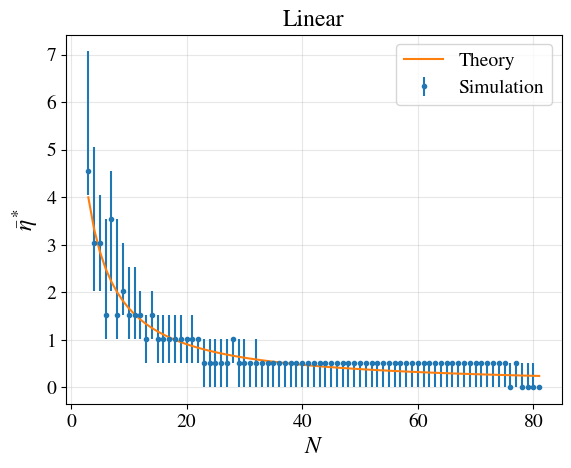

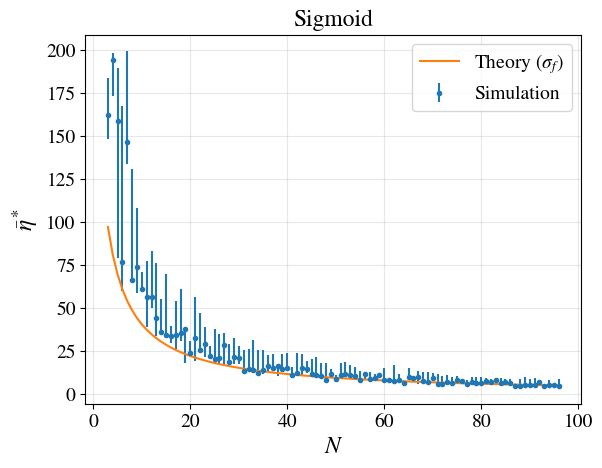

In [47]:
#Call eta_err function and generate error datasets
#eta_err(activation='linear', N_list=np.linspace(3,81,79).astype(int), spike_number=10, T=200)

# # Plot eta_opts
eta_opt_evolution(activation='linear', N_list=np.linspace(3,81,79).astype(int), spike_number=10, T=200, sigma=0.001, title='Linear', lin=True)
plt.savefig('eta_opt_lin_entwicklung.pdf')
plt.show()
# eta_opt_evolution(activation='sigmoid', N_list=np.linspace(3,150,148).astype(int), spike_number=10, T=200, sigma=0.001, title='Sigmoidfunktion',)
# plt.savefig('eta_opt_sig_entwicklung.pdf')
# plt.show()

# If one runs the hole network for equal start and target weight std one gets:
eta_opt_evolution(activation='sigmoid', N_list=np.linspace(3,96,94).astype(int), spike_number=10, T=200, sigma=0.001,title='Sigmoid', data_name='plot_samesig_vars')
plt.savefig('eta_opt_samesig_sig_entwicklung.pdf')
plt.show()

## Sigmoid: Non-Linear-Parameter dependency on $\sigma$

In [88]:
from scipy import integrate

#--------------------------------#
#            Eta Opt
#--------------------------------#
def g(x):
    return 1/(1+np.exp(-x))

def g_deriv(x):
    return np.exp(-x)/(1+np.exp(-x))**2

def g_dderiv(x):
    return 2*np.exp(-2*x)/(1+np.exp(-x))**3 - np.exp(-x)/(1+np.exp(-x))**2

def b(x,alpha_target):
    return (g_deriv(x)**2  + g(x)*g_dderiv(x) - alpha_target*g_dderiv(x))

def gauss(x, mu, sigma):
    return (1/np.sqrt(2*np.pi*sigma**2)) * np.exp(-(x-mu)**2 / (2*sigma**2))

def eta_opt(alpha_target, mu, sig):
    # First define the functions that will be integrated (prob.distr. * function)
    # Since g_deriv is symmetric we can calculate the positive integral and multiply by 2 for better precision
    mean_A = lambda x, mu, sigma: 2*gauss(x, mu, sigma)*g_deriv(x)**2
    mean_AB = lambda x, mu, sigma, alpha_target: gauss(x, mu, sigma)*b(x, alpha_target)*g_deriv(x)**2
    # Estimate the mean of the non-linear parameters by using integrate.quad
    factor1, _ = integrate.quad(mean_A, 0, 10*sig, args=(mu,sig))
    factor2, _ = integrate.quad(mean_AB, -10*sig, 10*sig, args=(mu,sig,alpha_target))
    # Determine the optimal learning rate
    factor = (factor1 / factor2)
    return factor

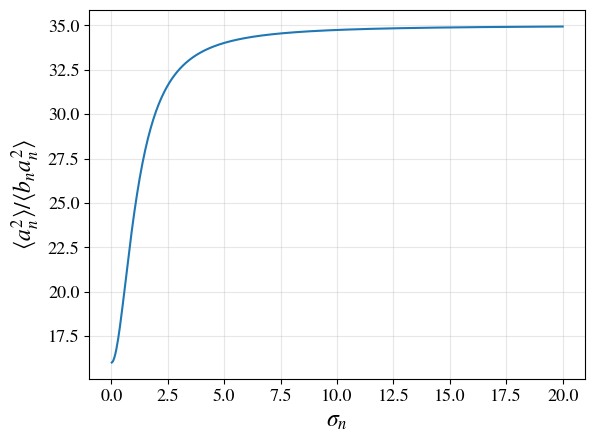

In [92]:

factor=[]
sig = np.linspace(0.02,20,500)
for sigma in sig:
    factor.append(eta_opt(alpha_target=0.1, mu=0, sig=sigma))

plt.plot(sig, factor)
plt.grid(alpha=0.3)
plt.xlabel(r'$\sigma_{n}$')
plt.ylabel(r'$\langle a^2_{n} \rangle / \langle b_{n}a^2_{n} \rangle$')
plt.savefig('factor.pdf')
plt.show()

# Distribution of $z_{n,t}$


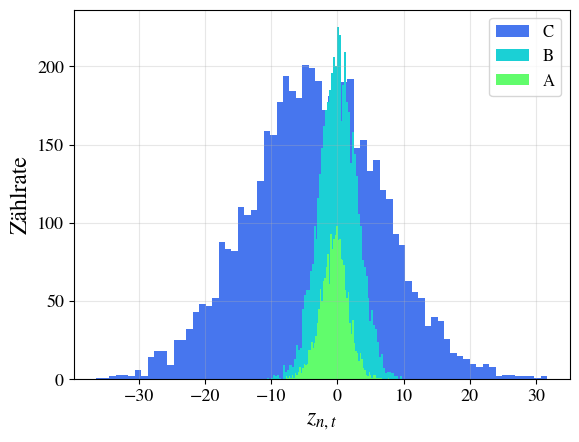

In [184]:
import seaborn as sns
from scipy import integrate

# Generate incoming spike train
def spike_train(N,T,N_spike):
    # Set underground
    underground = np.zeros((N,T))
    # Generate spikes
    signal = underground
    for input_neuron in range(0,N):
        index = random.sample(range(1, T), N_spike)
        for spike_time in index:
            # The amplitude of spikes
            spike_amplitude = 1 
            # Combine spikes with underground
            signal[input_neuron][spike_time] = spike_amplitude
    return signal

def Z_n_distribution(N,T,N_spike, label):
    # Initialize random weight values 
    weights = np.random.normal(0, 1, N)  
    # Generate inputs
    inputs = spike_train(N,T,N_spike)
    # Calculate z_n
    z = np.dot(weights, inputs)
    
    # Plot distribution
    plt.hist(z, bins=70, label=label)
    plt.xlabel(r'$z_{n,t}$')
    plt.ylabel(r'Zählrate')
    plt.legend()
    
sns.set_palette("turbo")
Z_n_distribution(N=1000, T=5000, N_spike=500, label='C')
Z_n_distribution(N=100, T=5000, N_spike=500, label='B')
Z_n_distribution(N=100, T=2000, N_spike=100, label='A')
plt.grid(alpha=0.3)
#plt.savefig('z_n_distirbution.pdf')
plt.show()

## Adaptded code for $\eta^*$

In [9]:

import random
from scipy import integrate
from scipy import special

class optimal_linear_perceptron:
    
    def __init__(self,
        sigma,  # std of the gaussian noise
        T,  # Vector length
        num_iterations,  # Number of iterations for weight update
        activation_type,  # Set activation function
        use_teacher,  # Use a teacher function to generate target
        plot_weight,  # Wether the evolution of weights should be plotted
        spike_number,  # Number of total spikes
        input_neuron_number,  # Number of neurons in input layer
        plot_errors = True,  # Wether to plot the error evolution
        samesig=False,
        ):
        
        self.sigma = sigma / np.sqrt(input_neuron_number*spike_number/T)
        self.T = T
        self.num_iterations = num_iterations
        self.activation_type = activation_type
        self.use_teacher = use_teacher
        self.plot_weight = plot_weight
        self.input_neuron_number =  input_neuron_number 
        self.spike_number = spike_number
        self.input_strength = self.spike_number/self.T
        self.eta = 0
        self.plot_errors = plot_errors
        # Collect errors for plot
        self.err = []
        self.err_WP = []
        # Collect first 3 weight values for plot
        self.w1 = []
        self.w2 = []
        self.w3 = []
        if samesig==True:
            self.sig_weight = np.sqrt(self.T/(self.spike_number*self.input_neuron_number))
        else:
            self.sig_weight = 1
       
   
    #----------------------------------------------------#
    #             Generate incoming spike train
    #----------------------------------------------------#  
    def spike_train(self):
        # Setting a seed, which garantees reproducebility of the trial
        random.seed(43)  
        # Set underground
        underground = np.zeros((self.input_neuron_number, self.T))
        # Generate spikes
        signal = underground
        for input_neuron in range(0, self.input_neuron_number):
            index = random.sample(range(1, self.T), self.spike_number)
            for spike_time in index:
                # The amplitude of spikes
                spike_amplitude = 1 
                # Combine spikes with underground
                signal[input_neuron][spike_time] = spike_amplitude
        return signal
    
       
    #----------------------------------------------------#
    #        Set start, teacher weights and target
    #----------------------------------------------------# 
        # Define teacher output 
    def teacher(self):
        # Create a RandomState object with a seed for reproducebility
        rng = np.random.RandomState(42)
        # Define target values for the weights
        self.teacher_weights = rng.normal(0, np.sqrt(self.T/(self.spike_number*self.input_neuron_number)), self.input_neuron_number)
        # Define the expected output based on the teacher weights
        self.expected_output = self.neuron(self.inputs, self.teacher_weights)
        
    # Initialize network weights and input
    def init_network(self):            
        # Initialize random weight values 
        self.weights = np.random.normal(0, self.sig_weight, self.input_neuron_number)  
        # Initialize random spike inputs
        self.inputs = self.spike_train()
        # Generate target
        if self.use_teacher == True:
            self.teacher()
        else:
            self.expected_output = np.random.randint(0, 2, size=(self.T)) 
    
    
    #----------------------------------------------------#
    #       Set neuron function and errors/updates
    #----------------------------------------------------# 
    # Define the operation of the neuron
    def neuron(self, inputs, weights):
        I_t = np.dot(weights,inputs)
        out = self.activation_func(I_t)
        return out    
        
    # Define activation function for three different functions
    def activation_func(self, x):
        z=0
        if self.activation_type == "linear":
            z = x 
        if self.activation_type == "sigmoid":
            z = 1.0/(1.0 + np.exp(-x)) 
        return z

    # Calculate the errors of the network predicitons
    def E(self, output, true_value):
        v = np.array(true_value) - np.array(output)
        return (1/(2*self.T)) * np.sum(v**2)  # scalar output

    # Define the update rule
    def weight_update(self, E_WP, E, noise):
        dw = - (self.eta/self.sigma**2) * (E_WP - E) * noise 
        return dw  
    
    
    #---------------------------------------------------------------------#
    #                            eta optimal
    #---------------------------------------------------------------------#
    def g(self, x):
        return 1/(1+np.exp(-x))

    def g_deriv(self, x):
        return np.exp(-x)/(1+np.exp(-x))**2

    def g_dderiv(self, x):
        return 2*np.exp(-2*x)/(1+np.exp(-x))**3 - np.exp(-x)/(1+np.exp(-x))**2
    
    def g_ddderiv(self, x):
        return -4*np.exp(-2*x)/(1+np.exp(-x))**3 + 6*np.exp(-3*x)/(1+np.exp(-x))**4 - self.g_dderiv(x)
    
    def g_dddderiv(self, x):
        return 8*np.exp(-2*x)/(1+np.exp(-x))**3 + 24*np.exp(-4*x)/(1+np.exp(-x))**5 - self.g_ddderiv(x)
    
    def c(self, x, target):
        return -(1/3)*(np.mean(target)-self.g(x))*self.g_ddderiv(x) + self.g_deriv(x)*self.g_dderiv(x)

    def b(self, x, target):
        return (self.g_deriv(x)**2 + self.g(x)*self.g_dderiv(x) - np.mean(target)*self.g_dderiv(x))

    def gauss(self, x, mu, sigma):
        return (1/np.sqrt(2*np.pi*sigma**2)) * np.exp(-(x-mu)**2 / (2*sigma**2))

    
    def eta_opt(self, target, mu, sig):
        # Calculate the optimal learning rate for linear activation
        eta_lin = 1/(self.input_strength * (self.input_neuron_number + 2))
        # Set optimal learning rate variable
        eta_optimal = 0
        # Set optimal learning rate for each activation funciton
        if self.activation_type == 'linear':
            eta_optimal = eta_lin
        elif self.activation_type == 'sigmoid':
            # First we define the functions that will be integrated (prob.distr. * function)
            # Since g_deriv is symmetric we can calculate the positive integral and multiply by 2 for better precision
            mean_A = lambda x, mu, sigma: 2*self.gauss(x, mu, sigma)*self.g_deriv(x)**2
            mean_AB = lambda x, mu, sigma, target: self.gauss(x, mu, sigma)*self.b(x, target)*self.g_deriv(x)**2
            # Estimate the mean of the non-linear parameters by using integrate.quad
            factor1, err1 = integrate.quad(mean_A, 0, np.infty, args=(mu,sig))
            factor2, err2 = integrate.quad(mean_AB, -200, 200, args=(mu,sig,target))
            # Determine the optimal learning rate
            factor = (factor1 / factor2)
            eta_optimal = eta_lin * factor
            
        # print(f'eta_optimal/eta_lin: {eta_optimal/eta_lin}')
        # print(f'eta_opt: {eta_optimal}')
        return eta_optimal
    
    #---------------------------------------------------------------------#
    #                            Plot weights
    #---------------------------------------------------------------------#
    def plot_weight_error_evolution(self):
        xspace = np.linspace(0,self.num_iterations, self.num_iterations)
        # Plot weight evolution
        if self.plot_weight == True:
            # Plotting only the first three weights
            visualize(xspace, self.w1, 'w1', 'Num iteration', 'Weight value', color='grey', linestyle='-', transparency=0.5)
            visualize(xspace, self.w2, 'w2', 'Num iteration', 'Weight value', color='orange', linestyle='-', transparency=0.5)
            visualize(xspace, self.w3, 'w3', 'Num iteration', 'Weight value', color='red', linestyle='-', transparency=0.5)
            # Plot the teacher weights
            plt.hlines(self.teacher_weights[0], -5, self.num_iterations + 5,  linestyles='--', color='grey')
            plt.hlines(self.teacher_weights[1], -5, self.num_iterations + 5, linestyles='--', color='orange')
            plt.hlines(self.teacher_weights[2], -5, self.num_iterations + 5, linestyles='--', color='red')
            plt.title(f'Activation func: {self.activation_type}')
            plt.show()
        # Plot the (perturbed and unperturbed) error evolution of the trial
        if self.plot_errors == True:
            visualize(xspace, self.err, 'err', 'Num iteration', 'Errors', color='blue', linestyle='-')
            visualize(xspace, self.err_WP, 'err_WP', 'Num iteration', 'Errors', color='green', linestyle='--', transparency=0.5)
            plt.title(f'Activation func: {self.activation_type}')
            plt.show()
            

    #---------------------------------------------------------------------#
    #                            Train network
    #---------------------------------------------------------------------#
    # Train the network using weight perturbation
    def network_training(self):            
        ETA = []
        # Initialize network (wet weights and input)
        self.init_network()
        # Determine optimal learning rate
        self.eta = self.eta_opt(target=self.expected_output, mu=0, sig=np.sqrt(self.input_strength*self.input_neuron_number))
        
        # Training
        for epoch in range(0,self.num_iterations):          
            ETA.append(self.eta)              
            # Save weight value to list
            self.w1.append(self.weights[0])
            self.w2.append(self.weights[1])
            self.w3.append(self.weights[2])
            
            # Reset output vector
            output = []
            output_WP = []
            # Define the noise
            noise = self.sigma * np.random.normal(loc=0., scale=1, size=(self.input_neuron_number,1)).flatten()

            # Unperturbed activations
            output = self.neuron(self.inputs, self.weights)                
            # Perturbed activations
            output_WP = self.neuron(self.inputs, self.weights + noise)
                
            # Compute the loss
            e = self.E(output, self.expected_output)
            e_WP = self.E(output_WP, self.expected_output)
            self.err.append(e)
            self.err_WP.append(e_WP)
                
            # Update the weights
            self.weights += self.weight_update(e_WP, e, noise) 
            z = np.dot(self.weights, self.inputs)
            self.eta = self.eta_opt(target=self.expected_output, mu=np.mean(z), sig=np.std(z))
            
        # Give out the output
        output = self.neuron(self.inputs, self.weights)
        # Call plot function
        self.plot_weight_error_evolution()
        return output, self.expected_output, self.err, self.err_WP, ETA

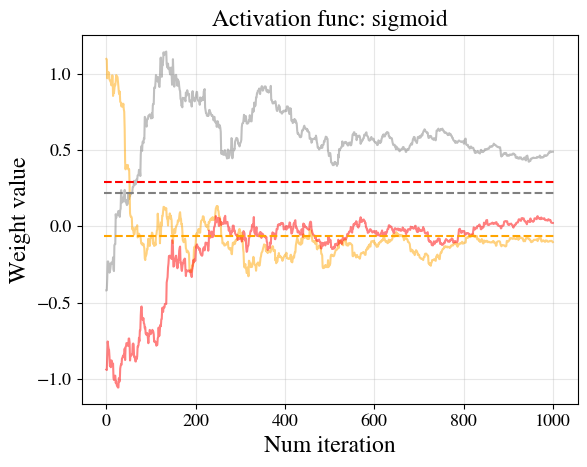

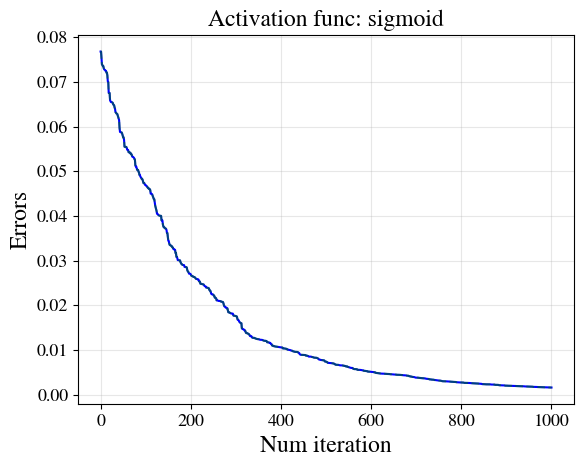

In [36]:
#---------------------------------------------------------------------#
#                          Execute network
#---------------------------------------------------------------------#
def exec_network(num_iterations, spike_number, T, N):
        for activation in ['sigmoid']:
                # Make individual selections for activation types
                if activation=='sigmoid':
                        sigma=0.001
                elif activation=='linear':
                        sigma=0.001
                # Create network instance
                readout = optimal_linear_perceptron(
                        sigma = sigma,  # std of the gaussian noise
                        T = T,  # Vector length
                        num_iterations = num_iterations,  # Number of iterations for weight update
                        activation_type = activation,  # Set activation function
                        use_teacher = True,  # Use teacher function
                        plot_weight = True,  # Plot the weight evolution
                        spike_number = spike_number,  # Total number of spikes
                        input_neuron_number = N,  # Number of neurons in input layer
                )

                # Train network and generate output
                output, expected_output, err, err_WP,_ = readout.network_training()
                
# Call exec_network
exec_network(num_iterations=1000, spike_number=10, T=200, N=100)

# Learning rate dynamics

In [10]:
#---------------------------------------------------------------------#
#                          Execute network
#---------------------------------------------------------------------#
def exec_network(num_iterations, spike_number, T, N):
        for activation in ['sigmoid']:
                # Make individual selections for activation types
                if activation=='step':
                        sigma=0.5
                elif activation=='sigmoid':
                        sigma=0.001
                elif activation=='linear':
                        sigma=0.001
                # Create network instance
                readout = optimal_linear_perceptron(
                        sigma = sigma,  # std of the gaussian noise
                        T = T,  # Vector length
                        num_iterations = num_iterations,  # Number of iterations for weight update
                        activation_type = activation,  # Set activation function
                        use_teacher = True,  # Use teacher function
                        plot_weight = False,  # Plot the weight evolution
                        spike_number = spike_number,  # Total number of spikes
                        input_neuron_number = N,  # Number of neurons in input layer
                        plot_errors=False,
                        samesig=True
                )

                # Train network and generate output
                output, expected_output, err, err_WP, ETA = readout.network_training()
                df = pd.DataFrame(ETA)
                df.to_csv(f'{activation}_ETA({N})samesig.csv', index=False)
                
# Call exec_network
exec_network(num_iterations=1000, spike_number=10, T=200, N=10)

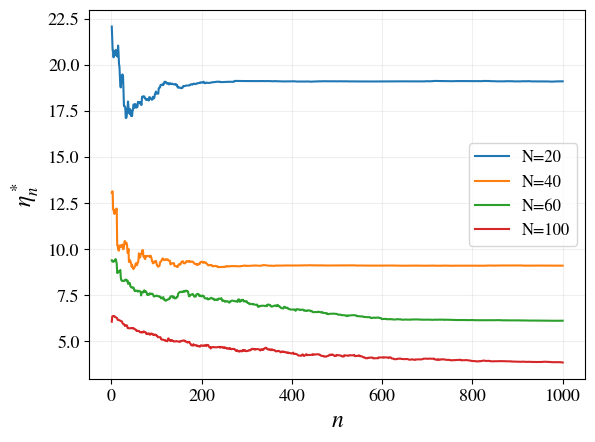

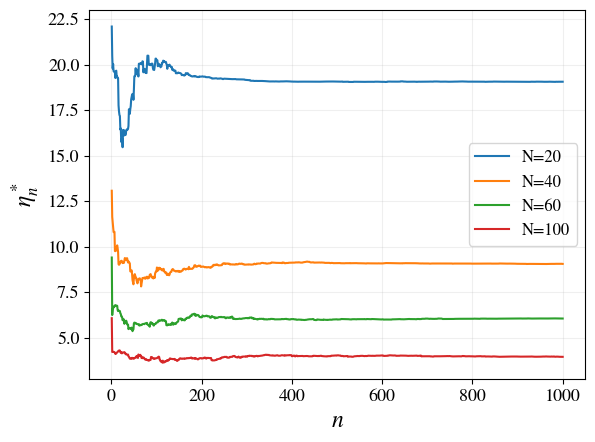

In [24]:
# For sigmoid
for N in [20,40,60,100]:
    df = pd.read_csv(f'sigmoid_ETA({N}).csv', engine='python')
    eta = df['0']
    plt.plot(np.linspace(1,1000,1000),eta, label=f'N={N}')
    plt.xlabel(r'$n$')
    plt.ylabel(r'$\eta^*_n$')

plt.legend()
plt.grid(alpha=0.2)
plt.show()


# For sigmoid
for N in [20,40,60,100]:
    df = pd.read_csv(f'sigmoid_ETA({N})samesig.csv', engine='python')
    eta = df['0']
    plt.plot(np.linspace(1,1000,1000),eta, label=f'N={N}')
    plt.xlabel(r'$n$')
    plt.ylabel(r'$\eta^*_n$')

plt.legend()
plt.grid(alpha=0.2)
plt.show()


# Mean error comparison with optimal learning


In [11]:
def optimal_mean_err(activation,
             num_iterations, 
             accuracy, 
             dataframe_meanErr_name, 
             dataframe_stdErr_name, 
             sigma,
             T = 200,
             N=100,
             ):
    
    LIST = []
    for i in range(0,accuracy):
        # Create network instance
        readout = optimal_linear_perceptron(
                sigma = sigma,  # std of the gaussian noise
                T = T,  # Vector length
                num_iterations = num_iterations,  # Number of iterations for weight update
                activation_type = activation,  # Set activation function
                use_teacher = True,  # Use teacher function
                plot_weight = False,  # Plot the weight evolution
                spike_number = 10,  # Total number of spikes
                input_neuron_number = N,  # Number of neurons in input layer
                plot_errors=False,
                )

        # Train network
        _, _, err, _, _ = readout.network_training()
        LIST.append(err)

    LIST = np.array(LIST)
    ERR_mean = []
    ERR_std = []
    for i in range(0,num_iterations):
        ERR_mean.append(np.mean(LIST[:,i]))
        ERR_std.append(np.std(LIST[:,i]))
    ERR_mean = np.array(ERR_mean)
    ERR_std = np.array(ERR_std)

    # Convert dictionary to DataFrame
    df1 = pd.DataFrame(ERR_mean)
    df2 = pd.DataFrame(ERR_std)

    # Save DataFrame as CSV
    df1.to_csv(dataframe_meanErr_name, index=False)
    df2.to_csv(dataframe_stdErr_name, index=False)

    # Give x-values for plot as return
    x = np.linspace(0,num_iterations-1, num_iterations)
    return x


# Plot data
def plot_mean_err(x, dataframe_meanErr_name, dataframe_stdErr_name, label='Mittlerer Fehler'):
    # Create a plot
    y = np.array(pd.read_csv(dataframe_meanErr_name, engine='python')).flatten()
    y_std = np.array(pd.read_csv(dataframe_stdErr_name, engine='python')).flatten()
    plt.plot(x, y, '-', label=label)
    
    plt.fill_between(x, np.maximum(y - y_std,0), np.maximum(y + y_std,0), alpha=0.3)
    # Titles and labels
    plt.xlabel(r'$n$')
    plt.ylabel(r'$E(n)$')
    plt.grid(alpha=0.3)
    plt.legend()

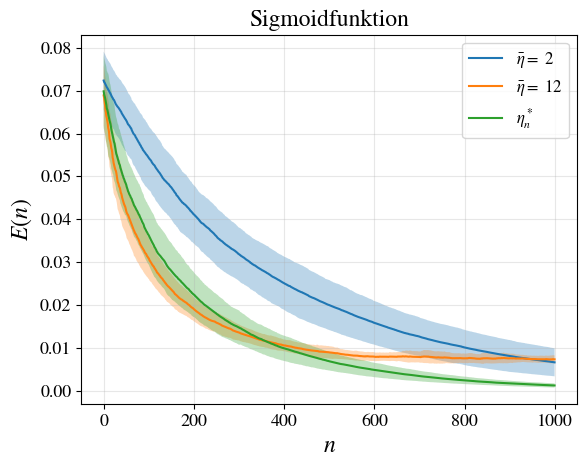

In [12]:
# Generate data
x = optimal_mean_err(activation='sigmoid',
        num_iterations = 1000, 
        accuracy=20, 
        dataframe_meanErr_name ='WP_compare_opt_MeanErr_sigmoid', 
        dataframe_stdErr_name ='WP_compare_opt_StdErr_sigmoid', 
        sigma=0.001,
        )

# Generate data
for eta in [2, 12]:
        x = mean_err(activation='sigmoid',
                num_iterations = 1000, 
                accuracy=20, 
                dataframe_meanErr_name =f'WP_MeanErr_sigmoid(ETA={eta})', 
                dataframe_stdErr_name =f'WP_StdErr_sigmoid(ETA={eta})', 
                sigma=0.001,
                eta=eta
                )

sns.set_palette("tab10")
# Plot data with fixed eta
for eta in [2, 12]:
        latex_string = r'$\bar{\eta}=$'
        plot_mean_err(x, f'WP_MeanErr_sigmoid(ETA={eta})', f'WP_StdErr_sigmoid(ETA={eta})', label=f'{latex_string} {eta}')

# Plot eta_opt at n=0
#plot_mean_err(x, f'WP_MeanErr_sigmoid(ETA=6.1)', f'WP_StdErr_sigmoid(ETA=6.1)', label=r'$\eta^*_0 \approx 6.1$')

# Plot data with optimal eta
plot_mean_err(x, 'WP_compare_opt_MeanErr_sigmoid', 'WP_compare_opt_StdErr_sigmoid', label=r'$\eta^*_n$')
plt.title('Sigmoidfunktion')
plt.legend()
plt.savefig('WP_compare_opt_MeanErr_sigmoid.pdf')
plt.show()

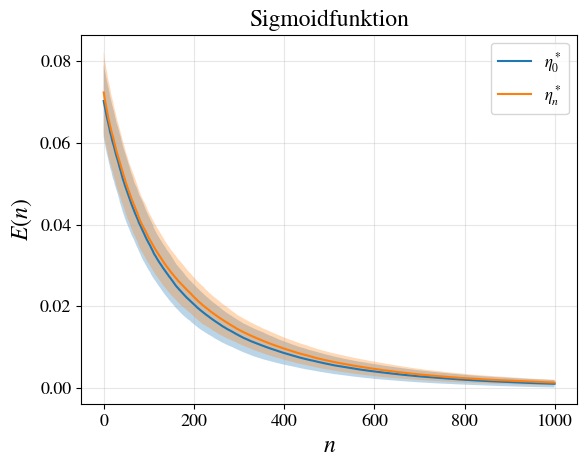

In [13]:
# Generate data
x = optimal_mean_err(activation='sigmoid',
        num_iterations = 1000, 
        accuracy=100, 
        dataframe_meanErr_name ='WP_compare_opt_MeanErr_sigmoid', 
        dataframe_stdErr_name ='WP_compare_opt_StdErr_sigmoid', 
        sigma=0.001,
        )

# Generate data
for eta in [6.1]:
        x = mean_err(activation='sigmoid',
                num_iterations = 1000, 
                accuracy=100, 
                dataframe_meanErr_name =f'WP_MeanErr_sigmoid(ETA={eta})', 
                dataframe_stdErr_name =f'WP_StdErr_sigmoid(ETA={eta})', 
                sigma=0.001,
                eta=eta
                )

# Plot eta_opt at n=0
plot_mean_err(x, f'WP_MeanErr_sigmoid(ETA=6.1)', f'WP_StdErr_sigmoid(ETA=6.1)', label=r'$\eta^*_0$')

# Plot data with optimal eta
plot_mean_err(x, 'WP_compare_opt_MeanErr_sigmoid', 'WP_compare_opt_StdErr_sigmoid', label=r'$\eta^*_n$')
plt.title('Sigmoidfunktion')
plt.legend()
plt.savefig('WP_compare_opt0_n_MeanErr_sigmoid.pdf')
plt.show()

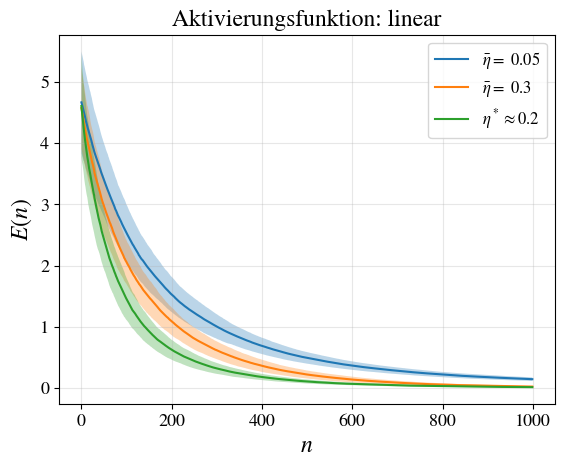

In [123]:
# # Generate data
# x = optimal_mean_err(activation='linear',
#         num_iterations = 1000, 
#         accuracy=100, 
#         dataframe_meanErr_name ='WP_compare_opt_MeanErr_linear', 
#         dataframe_stdErr_name ='WP_compare_opt_StdErr_linear', 
#         sigma=0.001,
#         )

# # Generate data
# for eta in [0.05, 0.3]:
#         x = mean_err(activation='linear',
#                 num_iterations = 1000, 
#                 accuracy=100, 
#                 dataframe_meanErr_name =f'WP_MeanErr_linear(ETA={eta})', 
#                 dataframe_stdErr_name =f'WP_StdErr_linear(ETA={eta})', 
#                 sigma=0.001,
#                 eta=eta
#                 )

# Plot data with fixed eta
for eta in [0.05, 0.3]:
        latex_string = r'$\bar{\eta}=$'
        plot_mean_err(x, f'WP_MeanErr_linear(ETA={eta})', f'WP_StdErr_linear(ETA={eta})', label=f'{latex_string} {eta}')

# Plot data with optimal eta
plot_mean_err(x, f'WP_MeanErr_linear(ETA=0.2)', f'WP_StdErr_linear(ETA=0.2)', label=r'$\eta^* \approx 0.2$')
plt.title('Aktivierungsfunktion: linear')
plt.legend()
plt.savefig('WP_compare_opt_MeanErr_linear.pdf')
plt.show()


# References

[1] Züge, Memmesheimer et al., *Weight Perturbation Learning Performs Similarly or Better than Node Perturbation
on Broad Classes of Temporally Extended Tasks*, 2022

[2] https://climate.nasa.gov/vital-signs/global-temperature/ , accessed on 05.04.2023

[3] Ian Goodfellow, *Deep Learning* 

[4] Dayan, Abott, *Theoretical neuroscience*, 2000